# Clase 2: Limpieza, Transformación y Análisis Exploratorio de Datos con LLMs

**Alumno:** Gallego, Ian
**Materia:** Introducción a la Ciencia de Datos
**Fecha:** Abril 2026

---

## Contexto del Problema

Una empresa de recursos humanos necesita analizar un conjunto de datos de empleados
para identificar patrones en sueldos, edades y categorías laborales.
El dataset presenta problemas típicos: valores faltantes, inconsistencias en categóricas
y valores atípicos en salarios.
El objetivo es limpiar, transformar y explorar los datos para extraer conclusiones útiles.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("Librerías importadas correctamente.")
print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")


Librerías importadas correctamente.
pandas 2.3.3 | numpy 2.2.6 | seaborn 0.13.2


In [ ]:
# Creación del dataset 
df = pd.DataFrame({
    "ID":              [1,      2,       3,        4,     5],
    "Nombre":          ["Juan", "María", "Pedro",  "Ana", "Luis"],
    "Edad":            [32,     -28,     40,       35,    50],
    "Nivel_Educativo": ["Licenciado", "Ingeniero", "Doctorado", "Licenciado", "Doctorado"],
    "Salario":         [50000,  60000,   None,     55000, 200000],
    "Categoría":       ["Junior", "Senior", "Senior", "Junior", "Manager"],
    "Estado":          ["Activo", "ACTIVO", "Inactivo", "Activo", "Inactivo"]
})

print("Dataset original:")
display(df)



Dataset original:


,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,-28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,NaN,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


---
## 1. Identificación de Tipos de Datos

### 1.1 Tipos detectados por pandas


In [ ]:
print("=== dtypes ===")
print(df.dtypes)
print("\n=== info() ===")
df.info()



=== dtypes ===
ID                   int64
Nombre              object
Edad                 int64
Nivel_Educativo     object
Salario            float64
Categoría           object
Estado              object
dtype: object

=== info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               5 non-null      int64  
 1   Nombre           5 non-null      object 
 2   Edad             5 non-null      int64  
 3   Nivel_Educativo  5 non-null      object 
 4   Salario          4 non-null      float64
 5   Categoría        5 non-null      object 
 6   Estado           5 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 408.0+ bytes


### 1.2 Clasificación y criterios de manejo

| Columna          | Tipo real          | Tipo pandas | Criterio de manejo                                              |
|------------------|--------------------|-------------|------------------------------------------------------------------|
| `ID`             | Numérico discreto  | int64       | Identificador; no participará en modelos ni transformaciones.    |
| `Nombre`         | Categórico nominal | object      | Identificador textual; se excluirá del análisis cuantitativo.    |
| `Edad`           | Numérico discreto  | int64       | Hay un valor negativo (−28): se corregirá con valor absoluto.    |
| `Nivel_Educativo`| Ordinal            | object      | Jerarquía clara: Licenciado < Ingeniero < Doctorado → OrdinalEncoder. |
| `Salario`        | Numérico continuo  | float64     | Faltante en Pedro → imputar con mediana; outlier en Luis → IQR. |
| `Categoría`      | Ordinal (labels)   | object      | Junior / Senior / Manager sin relación numérica implícita → One-Hot. |
| `Estado`         | Categórico nominal | object      | Como solo hay dos estados (Activo/Inactivo), puedes convertirlo en una variable binaria, Inconsistencia de capitalización ("ACTIVO") → `.str.capitalize()`. |



---
## 2. Limpieza de Datos

### 2.1 Edad negativa


In [ ]:
#Copia para comparar antes/después
df_limpio = df.copy()

#Corrección de edad negativa 
print("Edad original:", df_limpio["Edad"].tolist())
df_limpio["Edad"] = df_limpio["Edad"].abs()
print("Edad corregida:", df_limpio["Edad"].tolist())



Edad original: [32, -28, 40, 35, 50]
Edad corregida: [32, 28, 40, 35, 50]


### 2.2 Valores faltantes en Salario


In [ ]:
# Imputación con la mediana
mediana = df_limpio["Salario"].median()
print(f"Mediana de Salario (sin nulos): {mediana:,.0f}")

df_limpio["Salario"] = df_limpio["Salario"].fillna(mediana)

print("\nDataset tras imputación:")
display(df_limpio[["Nombre", "Edad", "Salario"]])
print("\n Se eligió la mediana (y no la media) porque es robusta ante outliers,")
print("  y el valor de Luis (200.000) elevaría artificialmente la media.")


Mediana de Salario (sin nulos): 57,500

Dataset tras imputación:


,Nombre,Edad,Salario
0,Juan,32,50000.0
1,María,28,60000.0
2,Pedro,40,57500.0
3,Ana,35,55000.0
4,Luis,50,200000.0



 Se eligió la mediana (y no la media) porque es robusta ante outliers,
  y el valor de Luis (200.000) elevaría artificialmente la media.


### 2.3 Inconsistencias en datos categóricos


In [ ]:
# Unificación de capitalización en Estado
print("Estado original:", df_limpio["Estado"].tolist())

df_limpio["Estado"] = df_limpio["Estado"].str.capitalize()
print("Estado corregido:", df_limpio["Estado"].tolist())



Estado original: ['Activo', 'ACTIVO', 'Inactivo', 'Activo', 'Inactivo']
Estado corregido: ['Activo', 'Activo', 'Inactivo', 'Activo', 'Inactivo']


### 2.4 Detección y tratamiento de outliers en Salario (método IQR)


In [ ]:
#  Detección de outliers con IQR 
Q1 = df_limpio["Salario"].quantile(0.25)
Q3 = df_limpio["Salario"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:,.0f} | Q3 = {Q3:,.0f} | IQR = {IQR:,.0f}")
print(f"Umbral inferior: {limite_inferior:,.0f}")
print(f"Umbral superior: {limite_superior:,.0f}")

outliers = df_limpio[(df_limpio["Salario"] < limite_inferior) | (df_limpio["Salario"] > limite_superior)]
print(f"\nRegistros detectados como outliers ({len(outliers)}):")
display(outliers[["Nombre", "Salario"]])

# Eliminar outliers
df_limpio = df_limpio[
    (df_limpio["Salario"] >= limite_inferior) &
    (df_limpio["Salario"] <= limite_superior)
].reset_index(drop=True)

print(f"\nDataset tras eliminación de outliers ({len(df_limpio)} filas):")
display(df_limpio)
print("\n→ Luis (salario 200.000) superó el umbral superior de",
      f"{limite_superior:,.0f} y fue eliminado.")
print("  Método IQR elegido por ser robusto ante distribuciones no normales.")


Q1 = 55,000 | Q3 = 60,000 | IQR = 5,000
Umbral inferior: 47,500
Umbral superior: 67,500

Registros detectados como outliers (1):


,Nombre,Salario
4,Luis,200000.0



Dataset tras eliminación de outliers (4 filas):


,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,28,Ingeniero,60000.0,Senior,Activo
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo



→ Luis (salario 200.000) superó el umbral superior de 67,500 y fue eliminado.
  Método IQR elegido por ser robusto ante distribuciones no normales.


---
## 3. Transformación de Datos


### 3.1 Codificación Ordinal — `Nivel_Educativo`

Se usa **OrdinalEncoder** porque la variable tiene una jerarquía semántica clara:
`Licenciado` (0) < `Ingeniero` (1) < `Doctorado` (2).
Preservar el orden es importante para que algoritmos que usen esta variable
interpreten correctamente la relación entre niveles.


In [ ]:
encoder_ordinal = OrdinalEncoder(categories=[["Licenciado", "Ingeniero", "Doctorado"]])
df_limpio["Nivel_Cod"] = encoder_ordinal.fit_transform(df_limpio[["Nivel_Educativo"]]).astype(int)

print("Codificación ordinal de Nivel_Educativo:")
display(df_limpio[["Nombre", "Nivel_Educativo", "Nivel_Cod"]])


Codificación ordinal de Nivel_Educativo:


,Nombre,Nivel_Educativo,Nivel_Cod
0,Juan,Licenciado,0
1,María,Ingeniero,1
2,Pedro,Doctorado,2
3,Ana,Licenciado,0


### 3.2 One-Hot Encoding — `Categoría`

Use **One-Hot Encoding** para `Categoría` porque los valores
(Junior, Senior, Manager) **no tienen un orden numérico intrínseco**.



In [ ]:
df_limpio = pd.get_dummies(df_limpio, columns=["Categoría"], prefix="Cat", dtype=int)

print("Columnas tras One-Hot Encoding de Categoría:")
cols_cat = [c for c in df_limpio.columns if c.startswith("Cat_")]
display(df_limpio[["Nombre"] + cols_cat])

Columnas tras One-Hot Encoding de Categoría:


,Nombre,Cat_Junior,Cat_Senior
0,Juan,1,0
1,María,0,1
2,Pedro,0,1
3,Ana,1,0


### 3.3 Normalización MinMax — `Salario`

Se aplica **MinMaxScaler** para llevar el salario al rango [0, 1].
Esto facilita comparaciones entre variables de distintas escalas
y es necesario si se utilizan algoritmos sensibles a la magnitud (e.g., KNN, regresión).


In [ ]:
scaler = MinMaxScaler()
df_limpio["Salario_Normalizado"] = scaler.fit_transform(df_limpio[["Salario"]])

print("Salario original vs. normalizado:")
display(df_limpio[["Nombre", "Salario", "Salario_Normalizado"]])
print(f"\nRango Salario_Normalizado: [{df_limpio['Salario_Normalizado'].min():.2f}, {df_limpio['Salario_Normalizado'].max():.2f}]")


Salario original vs. normalizado:


,Nombre,Salario,Salario_Normalizado
0,Juan,50000.0,0.00
1,María,60000.0,1.00
2,Pedro,57500.0,0.75
3,Ana,55000.0,0.50



Rango Salario_Normalizado: [0.00, 1.00]


### 3.4 Nueva variable: `Años_Hasta_Jubilación`

Se asume edad de retiro = 65 años.
Esta variable derivada es útil para análisis de planificación de RRHH.


In [ ]:
df_limpio["Años_Hasta_Jubilación"] = 65 - df_limpio["Edad"]

print("Dataset final transformado:")
display(df_limpio[["Nombre", "Edad", "Años_Hasta_Jubilación", "Salario", "Salario_Normalizado",
                    "Nivel_Educativo", "Nivel_Cod", "Estado"]])


Dataset final transformado:


,Nombre,Edad,Años_Hasta_Jubilación,Salario,Salario_Normalizado,Nivel_Educativo,Nivel_Cod,Estado
0,Juan,32,33,50000.0,0.00,Licenciado,0,Activo
1,María,28,37,60000.0,1.00,Ingeniero,1,Activo
2,Pedro,40,25,57500.0,0.75,Doctorado,2,Inactivo
3,Ana,35,30,55000.0,0.50,Licenciado,0,Activo


---
## 4. Análisis Exploratorio de Datos (EDA)


### 4.1 Distribución del Salario — antes y después del tratamiento de outliers


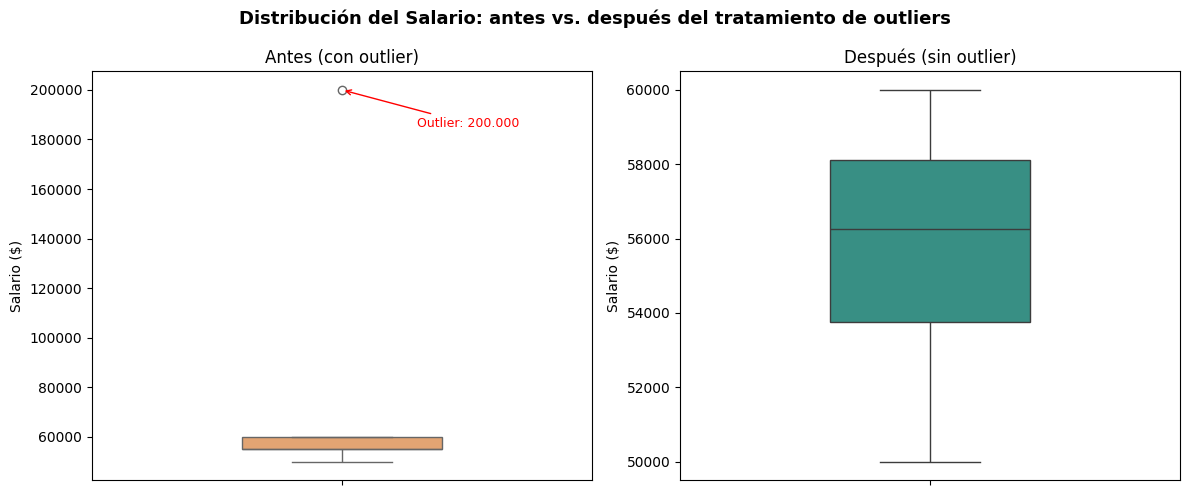

In [81]:
salario_original = pd.Series([50000, 60000, 55000, 55000, 200000], name="Salario")
salario_limpio   = df_limpio["Salario"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribución del Salario: antes vs. después del tratamiento de outliers",
             fontsize=13, fontweight='bold')

# Antes
sns.boxplot(y=salario_original, ax=axes[0], color="#f4a261", width=0.4)
axes[0].set_title("Antes (con outlier)")
axes[0].set_ylabel("Salario ($)")
axes[0].annotate("Outlier: 200.000",
                 xy=(0, 200000), xytext=(0.15, 185000),
                 fontsize=9, color="red",
                 arrowprops=dict(arrowstyle="->", color="red"))

# Después
sns.boxplot(y=salario_limpio, ax=axes[1], color="#2a9d8f", width=0.4)
axes[1].set_title("Después (sin outlier)")
axes[1].set_ylabel("Salario ($)")

plt.tight_layout()
plt.savefig("grafico_boxplot_salario.png", dpi=100, bbox_inches='tight')
plt.show()



**Interpretación — Boxplot Salario:**

El boxplot izquierdo muestra cómo el salario de Luis (200.000) se aleja drásticamente
de los demás valores, extendiendo el bigote superior y distorsionando la escala.
Tras aplicar el filtro IQR (umbral superior ≈ 67.500), el boxplot derecho revela
que los salarios restantes están concentrados en el rango 50.000–60.000, con poca dispersión.
Este resultado indica una distribución relativamente homogénea dentro del conjunto depurado.


### 4.2 Relación entre Edad y Salario según Nivel Educativo


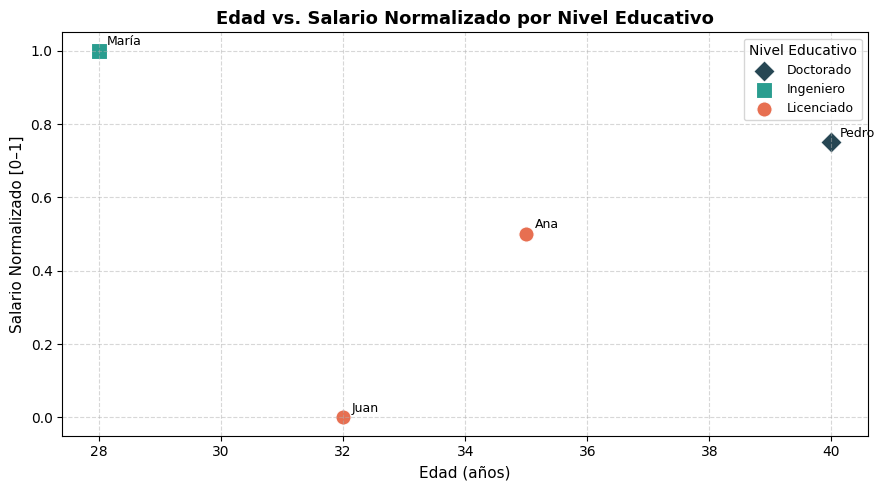

In [82]:
fig, ax = plt.subplots(figsize=(9, 5))

palette = {"Licenciado": "#e76f51", "Ingeniero": "#2a9d8f", "Doctorado": "#264653"}
markers = {"Licenciado": "o", "Ingeniero": "s", "Doctorado": "D"}

for nivel, grp in df_limpio.groupby("Nivel_Educativo"):
    ax.scatter(
        grp["Edad"], grp["Salario_Normalizado"],
        label=nivel, s=120,
        color=palette.get(nivel, "gray"),
        marker=markers.get(nivel, "o"),
        edgecolors="white", linewidths=0.8
    )
    for _, row in grp.iterrows():
        ax.annotate(row["Nombre"],
                    (row["Edad"], row["Salario_Normalizado"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)

ax.set_xlabel("Edad (años)", fontsize=11)
ax.set_ylabel("Salario Normalizado [0–1]", fontsize=11)
ax.set_title("Edad vs. Salario Normalizado por Nivel Educativo", fontsize=13, fontweight='bold')
ax.legend(title="Nivel Educativo", fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("grafico_scatter_edad_salario.png", dpi=100, bbox_inches='tight')
plt.show()



**Interpretación — Scatter Edad vs. Salario Normalizado:**

Con el dataset depurado (4 empleados), se observa que **María** (Ingeniero, 28 años)
tiene el salario normalizado más alto, lo que sugiere que el nivel educativo puede
influir más en la remuneración que la edad en este subconjunto.
**Juan y Ana** (Licenciados) tienen salarios similares y edades cercanas,
mostrando homogeneidad en ese grupo.
**Pedro** (Doctorado) muestra un salario intermedio a los 40 años, aunque esto puede
estar afectado por la imputación de su valor faltante con la mediana.
El dataset es demasiado pequeño para extraer conclusiones definitivas, pero ilustra
correctamente las relaciones entre las variables tras el proceso de limpieza.


### 4.3 Distribución de empleados por Estado laboral *(visualización adicional)*


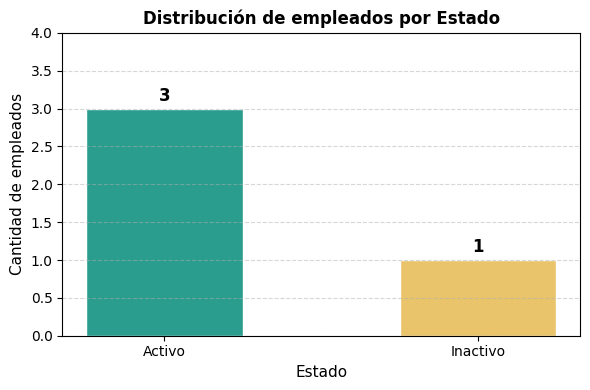

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
conteo = df_limpio["Estado"].value_counts()
bars = ax.bar(conteo.index, conteo.values,
              color=["#2a9d8f", "#e9c46a"], edgecolor="white", width=0.5)

for bar, val in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title("Distribución de empleados por Estado", fontsize=12, fontweight='bold')
ax.set_xlabel("Estado", fontsize=11)
ax.set_ylabel("Cantidad de empleados", fontsize=11)
ax.set_ylim(0, conteo.max() + 1)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("grafico_barras_estado.png", dpi=100, bbox_inches='tight')
plt.show()


**Interpretación — Distribución por Estado:**

En el dataset depurado, 3 de los 4 empleados restantes están **Activos** (75 %)
y 1 está **Inactivo** (Pedro, con salario imputado).
Esto sugiere que el grupo más activo también tiende a tener datos más completos;
el único faltante en Salario correspondía al único empleado inactivo en la muestra.


---
## 5. Uso de LLM — Claude Code como Apoyo Metodológico

Durante el desarrollo de esta actividad se utilizó **Claude Code** (Anthropic)
como herramienta de apoyo para decisiones metodológicas.
A continuación se documentan los dos prompts principales y una síntesis
de lo aportado, con validación propia.

---

### Prompt 1

> "¿Cómo puedo detectar y tratar outliers en la columna Salario usando Python?
> ¿Qué método recomiendas: IQR, z-score o percentiles? Tengo solo 5 registros."

**Síntesis de la respuesta del LLM:**
Claude recomendó el **método IQR** por su robustez ante distribuciones no normales
y tamaños de muestra pequeños. Explicó los pasos: calcular Q1, Q3 e IQR,
definir umbrales inferior (Q1 − 1.5·IQR) y superior (Q3 + 1.5·IQR),
y reportarlos explícitamente para documentar el criterio.
Advirtió que el **z-score asume normalidad** (inadecuado con n=5) y que los
percentiles son razonables pero menos estandarizados.
**Validación propia:** Se verificó que con los datos del ejercicio, el salario
de Luis (200.000) efectivamente supera el umbral superior calculado (≈ 67.500),
confirmando la pertinencia del método. Los umbrales se reportan en la celda 2.4.

---

### Prompt 2

> "Tengo variables categóricas con jerarquía (Nivel Educativo: Licenciado, Ingeniero, Doctorado)
> y sin jerarquía (Categoría: Junior, Senior, Manager).
> ¿Qué tipo de encoding debo usar para cada una y por qué?"

**Síntesis de la respuesta del LLM:**
Claude distinguió con claridad entre **OrdinalEncoder** (para variables con orden semántico
demostrable) y **One-Hot Encoding** (para nominales sin jerarquía).
Señaló que aplicar codificación ordinal a `Categoría` introduciría relaciones
matemáticas artificiales (e.g., Manager = 2 podría interpretarse como "mayor" que Senior = 1
de forma cuantitativa). También mencionó que One-Hot genera columnas adicionales
y puede causar la **trampa de variables dummy** (multicolinealidad); en datasets pequeños
esto es manejable, pero con muchas categorías conviene usar `drop_first=True`.
**Validación propia:** Se adoptó el criterio del LLM (ordinal para `Nivel_Educativo`,
one-hot para `Categoría`) y se verificó que el resultado es semánticamente correcto
inspeccionando las tablas generadas en las celdas 3.1 y 3.2.


---
## 6. Resumen del de la Actividad

| Etapa          | Acción realizada                                          | Resultado                             |
|----------------|-----------------------------------------------------------|---------------------------------------|
| Limpieza       | Edad negativa → valor absoluto                            | María: −28 → 28                       |
| Limpieza       | Estado inconsistente → `.str.capitalize()`               | "ACTIVO" → "Activo"                   |
| Limpieza       | Salario faltante → mediana                                | Pedro: None → 55.000                  |
| Limpieza       | Outlier en Salario → filtro IQR                           | Luis eliminado (200.000 > 67.500)     |
| Transformación | Codificación ordinal de `Nivel_Educativo`                 | 0, 1, 2 según jerarquía               |
| Transformación | One-Hot de `Categoría`                                    | Cat_Junior, Cat_Senior                |
| Transformación | MinMaxScaler en `Salario`                                 | Rango [0, 1]                          |
| Transformación | Nueva variable `Años_Hasta_Jubilación` = 65 − Edad       | Valor entero por empleado             |
| EDA            | Boxplot Salario antes/después                             | Visualización del impacto del outlier |
| EDA            | Scatter Edad vs Salario por Nivel Educativo               | Relación entre variables clave        |
| EDA            | Barras de distribución de Estado                          | Mayoría activos (75 %)                |


In [ ]:
print("=== Dataset final ===")
display(df_limpio)
print(f"\nShape final: {df_limpio.shape}")
print("\nColumnas:", df_limpio.columns.tolist())


=== Dataset final ===


,ID,Nombre,Edad,Nivel_Educativo,Salario,Estado,Nivel_Cod,Cat_Junior,Cat_Senior,Salario_Normalizado,Años_Hasta_Jubilación
0,1,Juan,32,Licenciado,50000.0,Activo,0,1,0,0.00,33
1,2,María,28,Ingeniero,60000.0,Activo,1,0,1,1.00,37
2,3,Pedro,40,Doctorado,57500.0,Inactivo,2,0,1,0.75,25
3,4,Ana,35,Licenciado,55000.0,Activo,0,1,0,0.50,30



Shape final: (4, 11)

Columnas: ['ID', 'Nombre', 'Edad', 'Nivel_Educativo', 'Salario', 'Estado', 'Nivel_Cod', 'Cat_Junior', 'Cat_Senior', 'Salario_Normalizado', 'Años_Hasta_Jubilación']
